# Beam Splitter — Digital Quantum Simulation

Based on *Cordero Encinar, Agusti & Sabin* (arXiv:2104.09442)

---

### Quick physics recap

We simulate the **beam-splitter unitary**:

$$U = e^{i\varepsilon(b^\dagger_+ a_- + b_+ a^\dagger_-)}$$

Restricting to **at most 1 photon per mode**, we need **4 qubits** (2 per mode).

| Fock state | Qubit state |
|---|---|
| \|0⟩₊\|0⟩₋ | \|0101⟩ |
| **\|1⟩₊\|0⟩₋** | **\|1001⟩** ← our initial state |
| \|0⟩₊\|1⟩₋ | \|0110⟩ |
| \|1⟩₊\|1⟩₋ | \|1010⟩ |

Starting from $|1\rangle_+|0\rangle_-$, the exact output is:

$$|\psi(\varepsilon)\rangle = \cos(\varepsilon)|1\rangle_+|0\rangle_- + i\sin(\varepsilon)|0\rangle_+|1\rangle_-$$

---
**Install:** `pip install qiskit qiskit-aer matplotlib`

## 1. Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

## 2. The Pauli-exponential gate

Every term in the beam splitter Hamiltonian has the form $e^{i\theta\, P_0\otimes P_1\otimes P_2\otimes P_3}$.

We implement it in three steps:
1. **Basis rotations** — bring each qubit into the Z basis (H for X, Sdg·H for Y)
2. **CNOT ladder** — accumulate the parity of all qubits onto the last one
3. **Rz(−2θ)** — the actual rotation, then uncompute both steps above

In [5]:
def pauli_exp(qc, paulis, theta):
    """
    Append exp(i * theta * P0⊗P1⊗P2⊗P3) to qc (qubits 0-3).
    paulis : 4-char string, e.g. 'XXXX' or 'XYYX'
    theta  : rotation angle
    """
    qubits = [i for i, p in enumerate(paulis) if p != 'I']
    ps     = [p for p in paulis if p != 'I']

    # 1. Rotate into Z basis
    for q, p in zip(qubits, ps):
        if p == 'X':
            qc.h(q)
        elif p == 'Y':
            qc.sdg(q)
            qc.h(q)

    # 2. CNOT parity ladder onto last qubit
    for i in range(len(qubits) - 1):
        qc.cx(qubits[i], qubits[i + 1])

    # 3. Rz on last qubit  (Qiskit: Rz(lam) = e^{-i*lam/2 * Z}, so lam = -2*theta)
    qc.rz(-2 * theta, qubits[-1])

    # 4. Uncompute CNOT ladder
    for i in reversed(range(len(qubits) - 1)):
        qc.cx(qubits[i], qubits[i + 1])

    # 5. Uncompute basis rotations
    for q, p in zip(qubits, ps):
        if p == 'X':
            qc.h(q)
        elif p == 'Y':
            qc.h(q)
            qc.s(q)

## 3. Build the beam splitter circuit

The bosonic operator maps to **8 four-qubit Pauli terms** (paper Eq. 38):

$$b^\dagger_+a_- + \text{h.c.} \;\rightarrow\; \tfrac{1}{8}\bigl(+XXXX - XYYX + XYXY + XXYY + YYXX + YXYX - YXXY + YYYY\bigr)$$

So $U = \prod_{k=1}^{8} e^{i\cdot\text{sign}_k\cdot\varepsilon/8\cdot P_k}$

In [6]:
# The 8 Pauli terms and their signs (from Eq. 38 of the paper)
PAULI_TERMS = [
    ('XXXX', +1), ('XYYX', -1), ('XYXY', +1), ('XXYY', +1),
    ('YYXX', +1), ('YXYX', +1), ('YXXY', -1), ('YYYY', +1),
]

def build_beam_splitter(eps):
    """
    Build the 4-qubit beam splitter circuit for parameter eps.
    Initial state: |1>+|0>-  mapped to qubit state |1001>
    """
    qc = QuantumCircuit(4, 4)

    # Prepare |1001>: flip qubits 0 and 3
    qc.x(0)
    qc.x(3)
    qc.barrier()

    # Apply all 8 Pauli-exponential terms
    for pauli, sign in PAULI_TERMS:
        pauli_exp(qc, pauli, sign * eps / 8)

    qc.barrier()
    qc.measure(range(4), range(4))
    return qc

## 4. Draw the circuit

Let's look at the circuit for $\varepsilon = 0.3$.

Depth: 86  |  Gates: OrderedDict([('h', 64), ('cx', 48), ('sdg', 16), ('s', 16), ('rz', 8), ('measure', 4), ('x', 2), ('barrier', 2)])


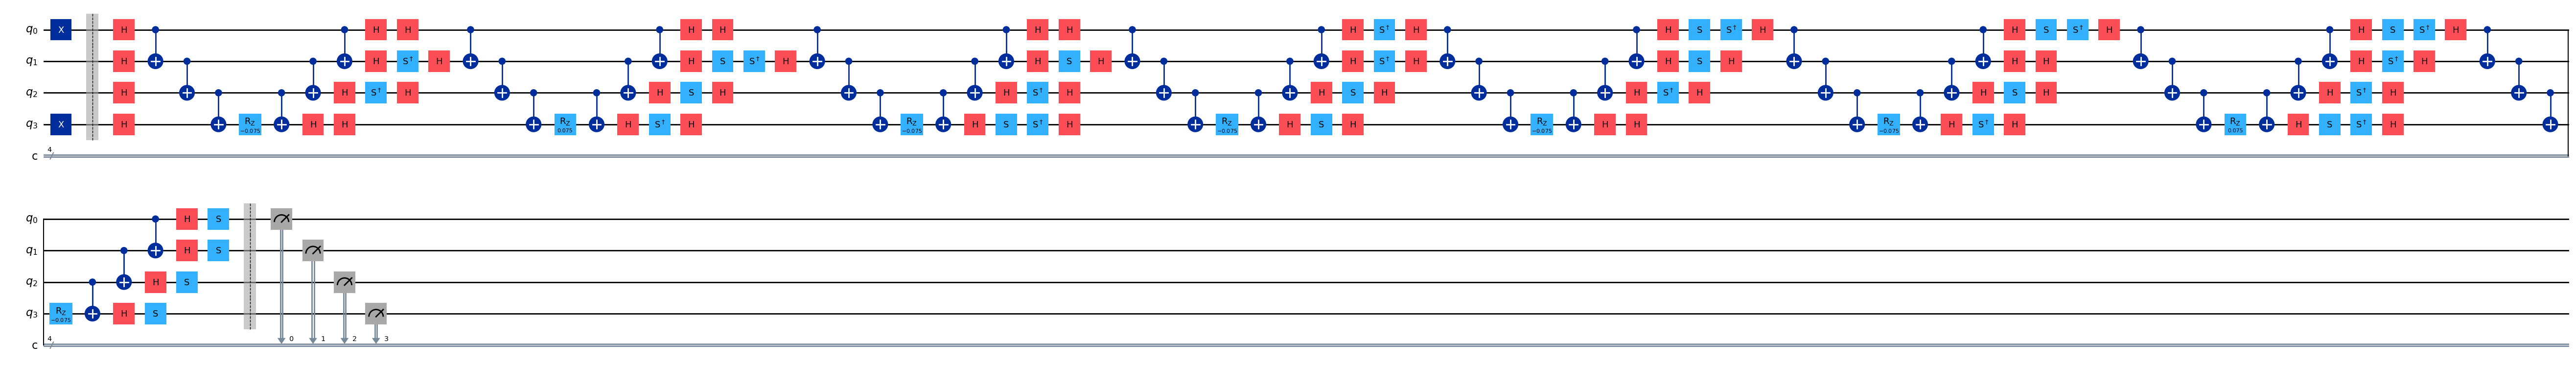

In [7]:
qc = build_beam_splitter(eps=0.3)
print(f"Depth: {qc.depth()}  |  Gates: {qc.count_ops()}")
qc.draw('mpl', fold=80)

Transpiled — Depth: 53  |  Gates: OrderedDict([('cx', 34), ('u2', 14), ('rz', 8), ('unitary', 5), ('h', 4), ('measure', 4), ('x', 2), ('barrier', 2)])


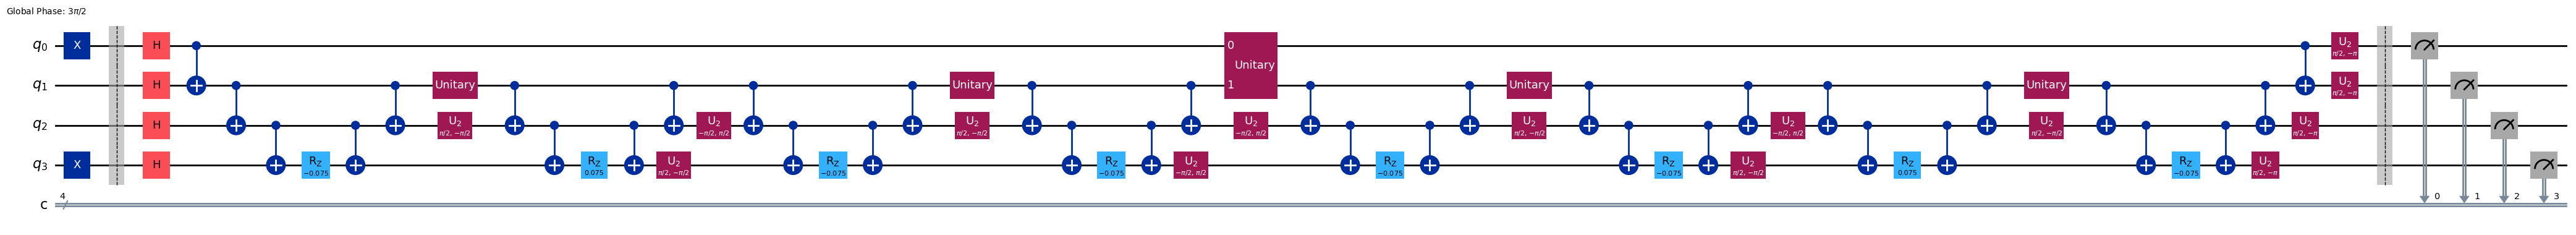

In [8]:
# Transpiled (optimised) version
backend = AerSimulator()
tqc = transpile(qc, backend, optimization_level=3)
print(f"Transpiled — Depth: {tqc.depth()}  |  Gates: {tqc.count_ops()}")
tqc.draw('mpl', fold=80)

## 5. Run a single simulation

We only keep counts from the **4 valid Fock states** (`0101`, `0110`, `1001`, `1010`) — this is called **post-selection**.

In [9]:
VALID = {'0101', '0110', '1001', '1010'}

def simulate(eps, shots=8192):
    qc      = build_beam_splitter(eps)
    tqc     = transpile(qc, AerSimulator(), optimization_level=3)
    counts  = AerSimulator().run(tqc, shots=shots).result().get_counts()

    # Post-select: keep only valid Fock states
    valid   = {s: c for s, c in counts.items() if s in VALID}
    total   = sum(valid.values())

    return {
        'p_1001': valid.get('1001', 0) / total,   # measured P(|1>+|0>-)
        'p_0110': valid.get('0110', 0) / total,   # measured P(|0>+|1>-)
        'exact_1001': np.cos(eps)**2,              # cos²(ε)
        'exact_0110': np.sin(eps)**2,              # sin²(ε)
        'valid_fraction': sum(valid.values()) / sum(counts.values()),
    }

In [10]:
eps = np.pi / 6   # 30 degrees
r   = simulate(eps)

print(f"ε = π/6 ≈ {eps:.3f}")
print(f"")
print(f"State       Measured   Exact")
print(f"|1>+|0>-    {r['p_1001']:.3f}      {r['exact_1001']:.3f}  (cos²ε)")
print(f"|0>+|1>-    {r['p_0110']:.3f}      {r['exact_0110']:.3f}  (sin²ε)")
print(f"")
print(f"Post-selection fraction: {r['valid_fraction']:.3f}")

ε = π/6 ≈ 0.524

State       Measured   Exact
|1>+|0>-    0.753      0.750  (cos²ε)
|0>+|1>-    0.247      0.250  (sin²ε)

Post-selection fraction: 1.000


## 6. Sweep over ε and plot

Run the simulation across a range of values and compare measured probabilities to the exact analytical result.

In [11]:
eps_values = np.linspace(0.1, np.pi / 2, 16)
results    = [simulate(e) for e in eps_values]

p_1001_sim   = [r['p_1001']       for r in results]
p_0110_sim   = [r['p_0110']       for r in results]
p_1001_exact = [r['exact_1001']   for r in results]
p_0110_exact = [r['exact_0110']   for r in results]

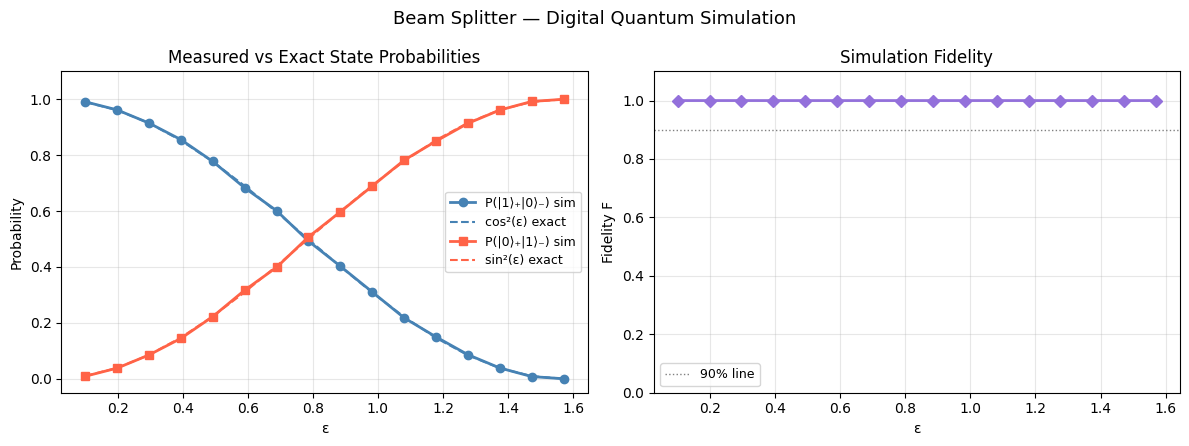

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Beam Splitter — Digital Quantum Simulation', fontsize=13)

# Left: state probabilities vs exact
ax = axes[0]
ax.plot(eps_values, p_1001_sim,   'o-', color='steelblue',  label='P(|1⟩₊|0⟩₋) sim',  lw=2, ms=6)
ax.plot(eps_values, p_1001_exact, '--', color='steelblue',  label='cos²(ε) exact',      lw=1.5)
ax.plot(eps_values, p_0110_sim,   's-', color='tomato',     label='P(|0⟩₊|1⟩₋) sim',  lw=2, ms=6)
ax.plot(eps_values, p_0110_exact, '--', color='tomato',     label='sin²(ε) exact',      lw=1.5)
ax.set_xlabel('ε')
ax.set_ylabel('Probability')
ax.set_title('Measured vs Exact State Probabilities')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.1)
ax.grid(True, alpha=0.3)

# Right: fidelity
#   F ≈ (√(P_meas(1001)·cos²ε) + √(P_meas(0110)·sin²ε))²
fidelities = [
    (np.sqrt(r['p_1001'] * r['exact_1001']) + np.sqrt(r['p_0110'] * r['exact_0110'])) ** 2
    for r in results
]

ax2 = axes[1]
ax2.plot(eps_values, fidelities, 'D-', color='mediumpurple', lw=2, ms=6)
ax2.axhline(0.9, color='gray', lw=1, ls=':', label='90% line')
ax2.set_xlabel('ε')
ax2.set_ylabel('Fidelity F')
ax2.set_title('Simulation Fidelity')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. For different values of ε

Change `eps` below and re-run the cell to explore the beam splitter at different angles.

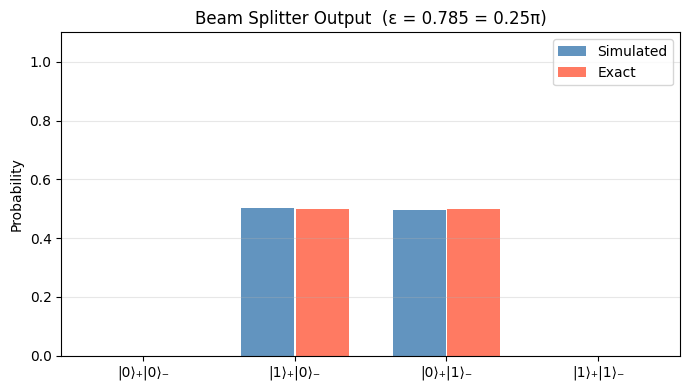

At ε = π/4: equal superposition → both modes get 50% probability


In [ ]:
eps = np.pi / 4  

r = simulate(eps)

labels = ['|0⟩₊|0⟩₋', '|1⟩₊|0⟩₋', '|0⟩₊|1⟩₋', '|1⟩₊|1⟩₋']
states = ['0101',       '1001',       '0110',       '1010']

# Re-run full counts for bar chart
qc     = build_beam_splitter(eps)
tqc    = transpile(qc, AerSimulator(), optimization_level=3)
counts = AerSimulator().run(tqc, shots=8192).result().get_counts()
valid  = {s: counts.get(s, 0) for s in states}
total  = sum(valid.values())
probs  = [valid[s] / total for s in states]
exact  = [0, np.cos(eps)**2, np.sin(eps)**2, 0]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.18, probs, 0.35, label='Simulated', color='steelblue', alpha=0.85)
ax.bar(x + 0.18, exact, 0.35, label='Exact',     color='tomato',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Probability')
ax.set_title(f'Beam Splitter Output  (ε = {eps:.3f} = {eps/np.pi:.2f}π)')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"At ε = π/4: equal superposition → both modes get 50% probability")

## 8. Simulation on the Real Hardware

In [14]:
eps = 0.785 # pi/4
qc = build_beam_splitter(eps)

In [15]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(channel="ibm_cloud", 
                                  token="_dErpIFKvYQ3EvXje9uL8BA3aKJpzQh8Xh7mGlTfEycf",
                                  instance="crn:v1:bluemix:public:quantum-computing:us-east:a/c908c48aec2d4584991b2e8f80c2b715:c8dbc073-2632-40b3-bfd9-c68d40f95178::",
                                  overwrite="True")

In [16]:
service = QiskitRuntimeService()
backend = service.least_busy(min_num_qubits=5)
print(backend)

<IBMBackend('ibm_marrakesh')>


In [17]:
from qiskit_ibm_runtime import SamplerV2


sampler = SamplerV2(backend)

In [18]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
isa_circuit = pm.run(qc)

sampler = SamplerV2(backend)
job = sampler.run([isa_circuit], shots=8192)

print(f"Job ID: {job.job_id()}")
print("Job submitted to queue. You can check the dashboard or wait for it to finish.")

result = job.result()
counts = result[0].data.c.get_counts()
print(counts)

Job ID: d7j8ka1s7cos73ejjf50
Job submitted to queue. You can check the dashboard or wait for it to finish.
{'0110': 3383, '1001': 3386, '1000': 156, '1110': 230, '0001': 372, '1010': 171, '0100': 27, '0000': 11, '0010': 271, '0111': 32, '0101': 53, '1111': 8, '1011': 27, '1101': 56, '1100': 4, '0011': 5}


In [19]:
from qiskit.visualization import plot_histogram

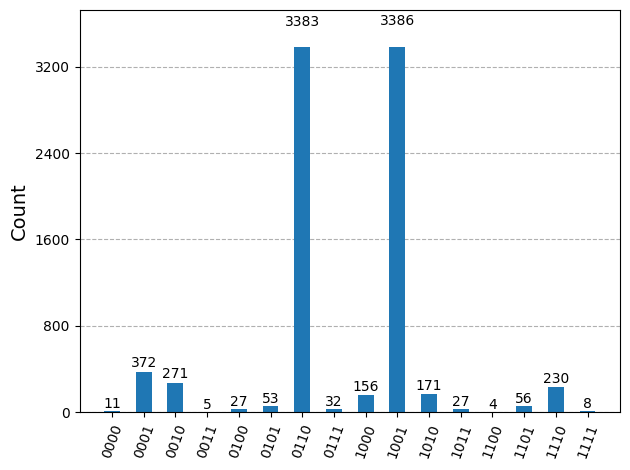

In [22]:
plot_histogram(counts)

In [ ]:
def plot_hardware_results(counts, eps):

    # 1. Define the target states and their physics labels
    states = ['0101', '1001', '0110', '1010']
    labels = ['|0⟩₊|0⟩₋', '|1⟩₊|0⟩₋', '|0⟩₊|1⟩₋', '|1⟩₊|1⟩₋']

    # 2. Apply Post-Selection safely (defaults to 0 if the state was never measured)
    valid_counts = {s: counts.get(s, 0) for s in states}
    total_valid = sum(valid_counts.values())
    total_shots = sum(counts.values())

    # Prevent division by zero if hardware noise completely destroyed the state
    if total_valid == 0:
        print("Error: No valid 1-photon states found in the counts dictionary.")
        return

    # 3. Normalize valid counts to get simulated probabilities
    hw_probs = [valid_counts[s] / total_valid for s in states]

    # 4. Calculate exact theoretical probabilities for comparison
    exact_probs = [0, np.cos(eps)**2, np.sin(eps)**2, 0]

    # 5. Plotting
    x = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.bar(x - 0.18, hw_probs, 0.35, label='Hardware (Post-Selected)', color='mediumseagreen', alpha=0.85)
    ax.bar(x + 0.18, exact_probs, 0.35, label='Exact', color='tomato', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Probability')
    ax.set_title(f'Hardware Beam Splitter Output (ε = {eps:.3f} = {eps/np.pi:.2f}π)')
    ax.legend()
    
    # Dynamically scale the Y-axis based on the highest probability
    max_y = max(max(hw_probs), max(exact_probs))
    ax.set_ylim(0, max_y + 0.1) 
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    # Print a summary report of the hardware's performance
    print(f"--- Hardware Performance Report ---")
    print(f"Total Raw Shots: {total_shots}")
    print(f"Valid 1-Photon Shots: {total_valid} ({total_valid/total_shots:.1%} retention)")
    print(f"-----------------------------------")
    print(f"|1⟩₊|0⟩₋  ->  Hardware: {hw_probs[1]:.4f}  |  Exact: {exact_probs[1]:.4f}")
    print(f"|0⟩₊|1⟩₋  ->  Hardware: {hw_probs[2]:.4f}  |  Exact: {exact_probs[2]:.4f}")
    print(f"Leakage to |0⟩₊|0⟩₋ : {hw_probs[0]:.4f}")
    print(f"Leakage to |1⟩₊|1⟩₋ : {hw_probs[3]:.4f}")

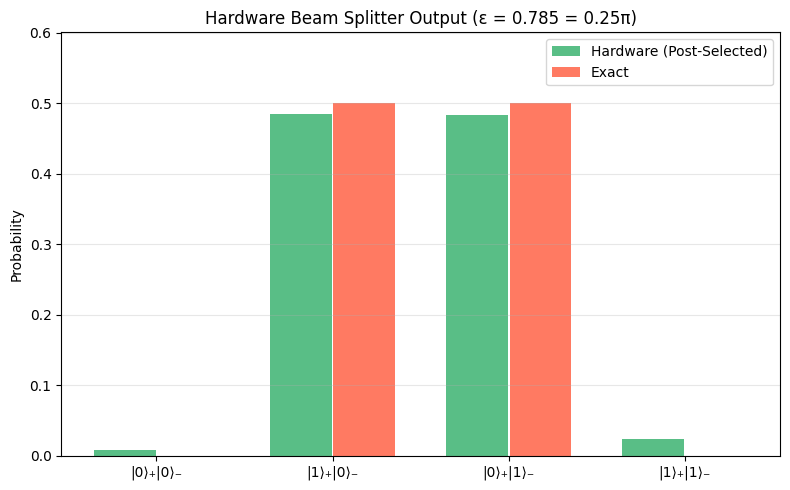

--- Hardware Performance Report ---
Total Raw Shots: 8192
Valid 1-Photon Shots: 6993 (85.4% retention)
-----------------------------------
|1⟩₊|0⟩₋  ->  Hardware: 0.4842  |  Exact: 0.5004
|0⟩₊|1⟩₋  ->  Hardware: 0.4838  |  Exact: 0.4996
Leakage to |0⟩₊|0⟩₋ : 0.0076
Leakage to |1⟩₊|1⟩₋ : 0.0245


In [24]:
plot_hardware_results(counts, eps)

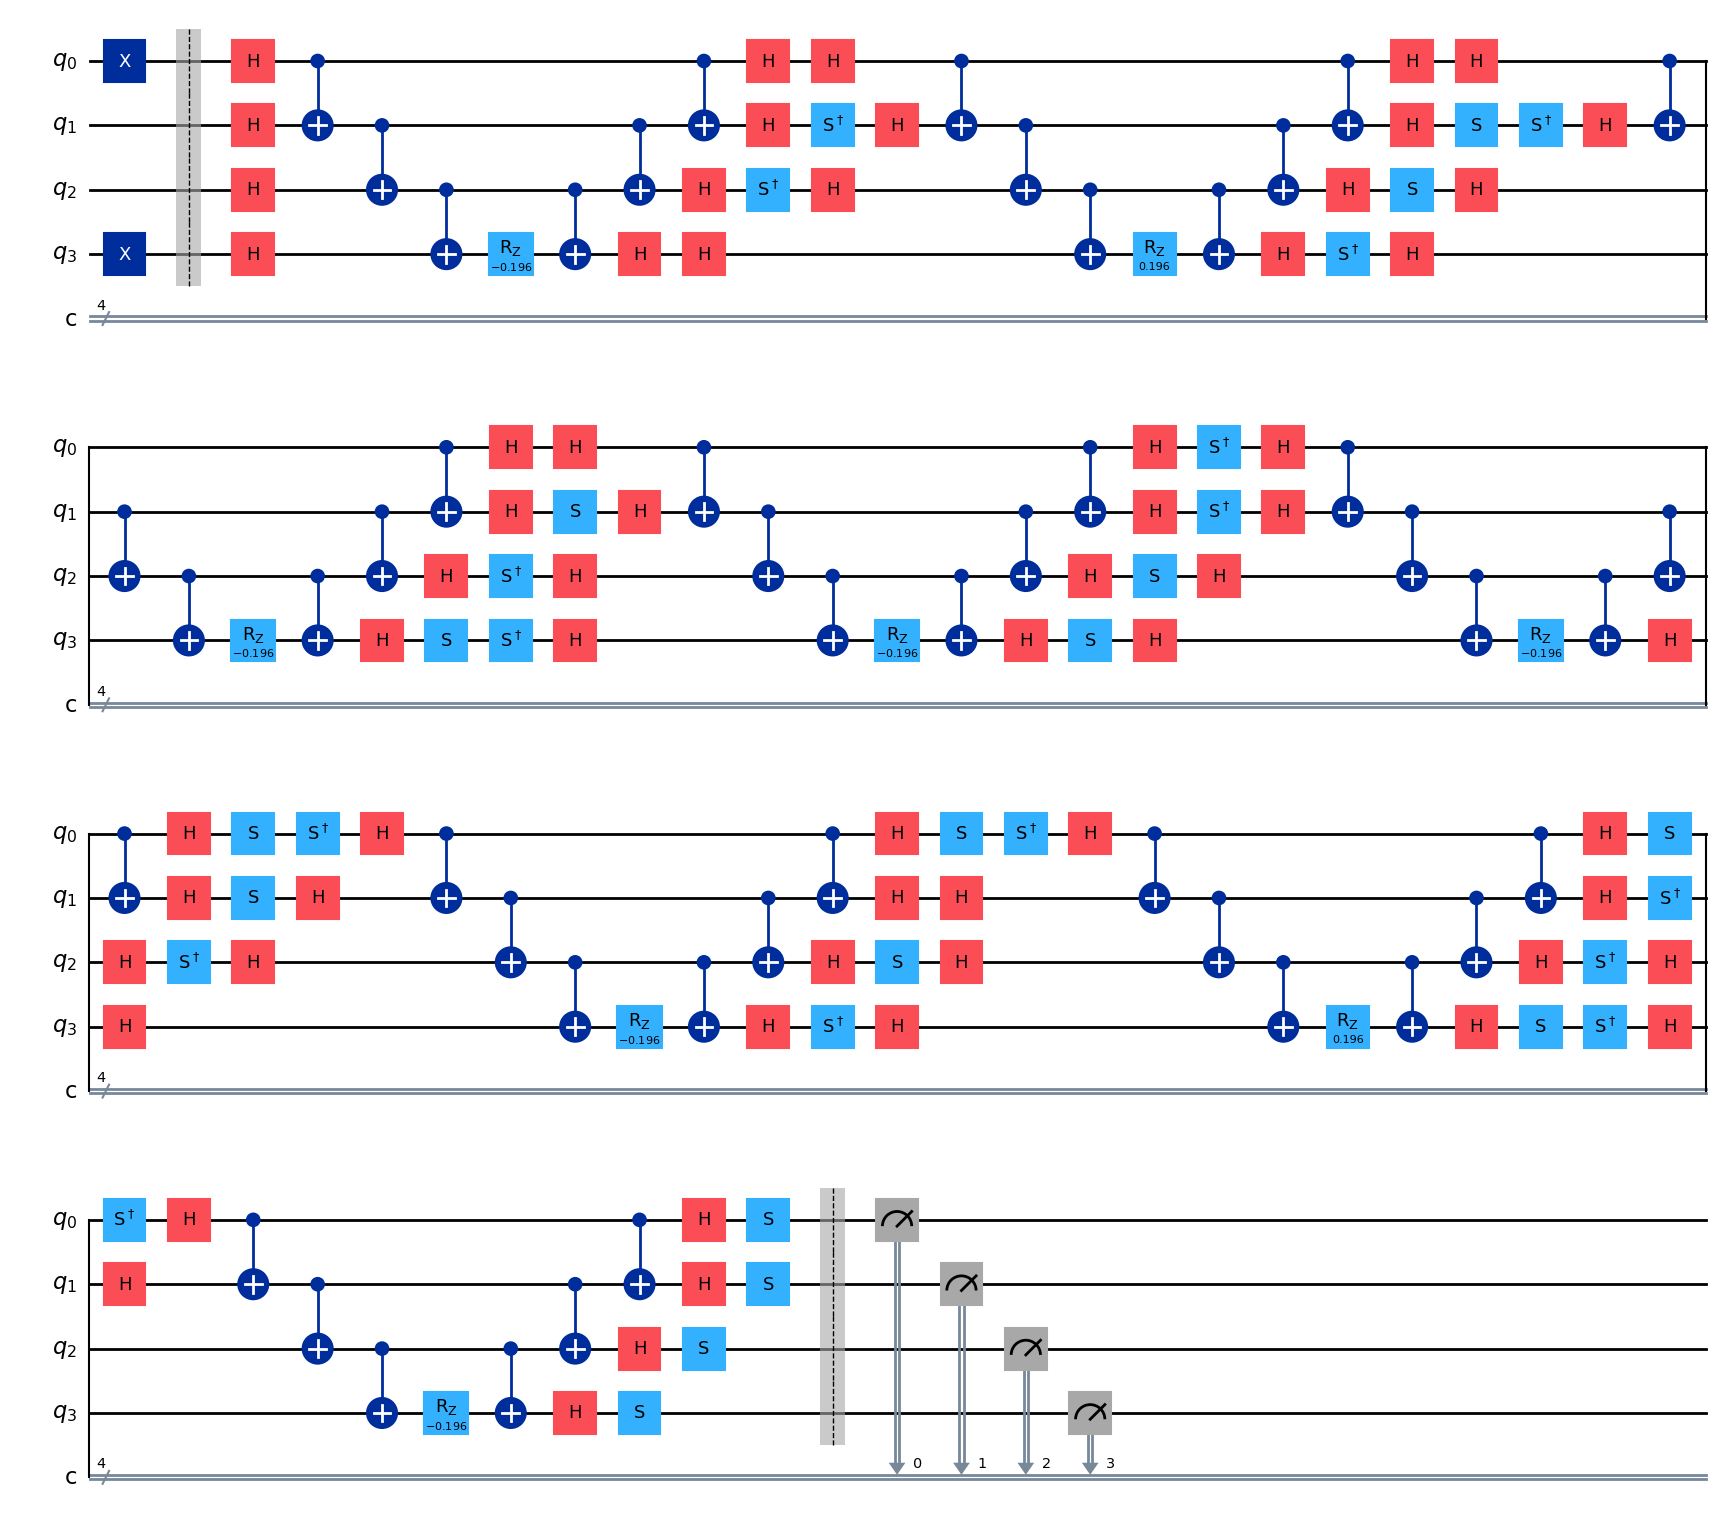

In [25]:
qc.draw('mpl',idle_wires=False)

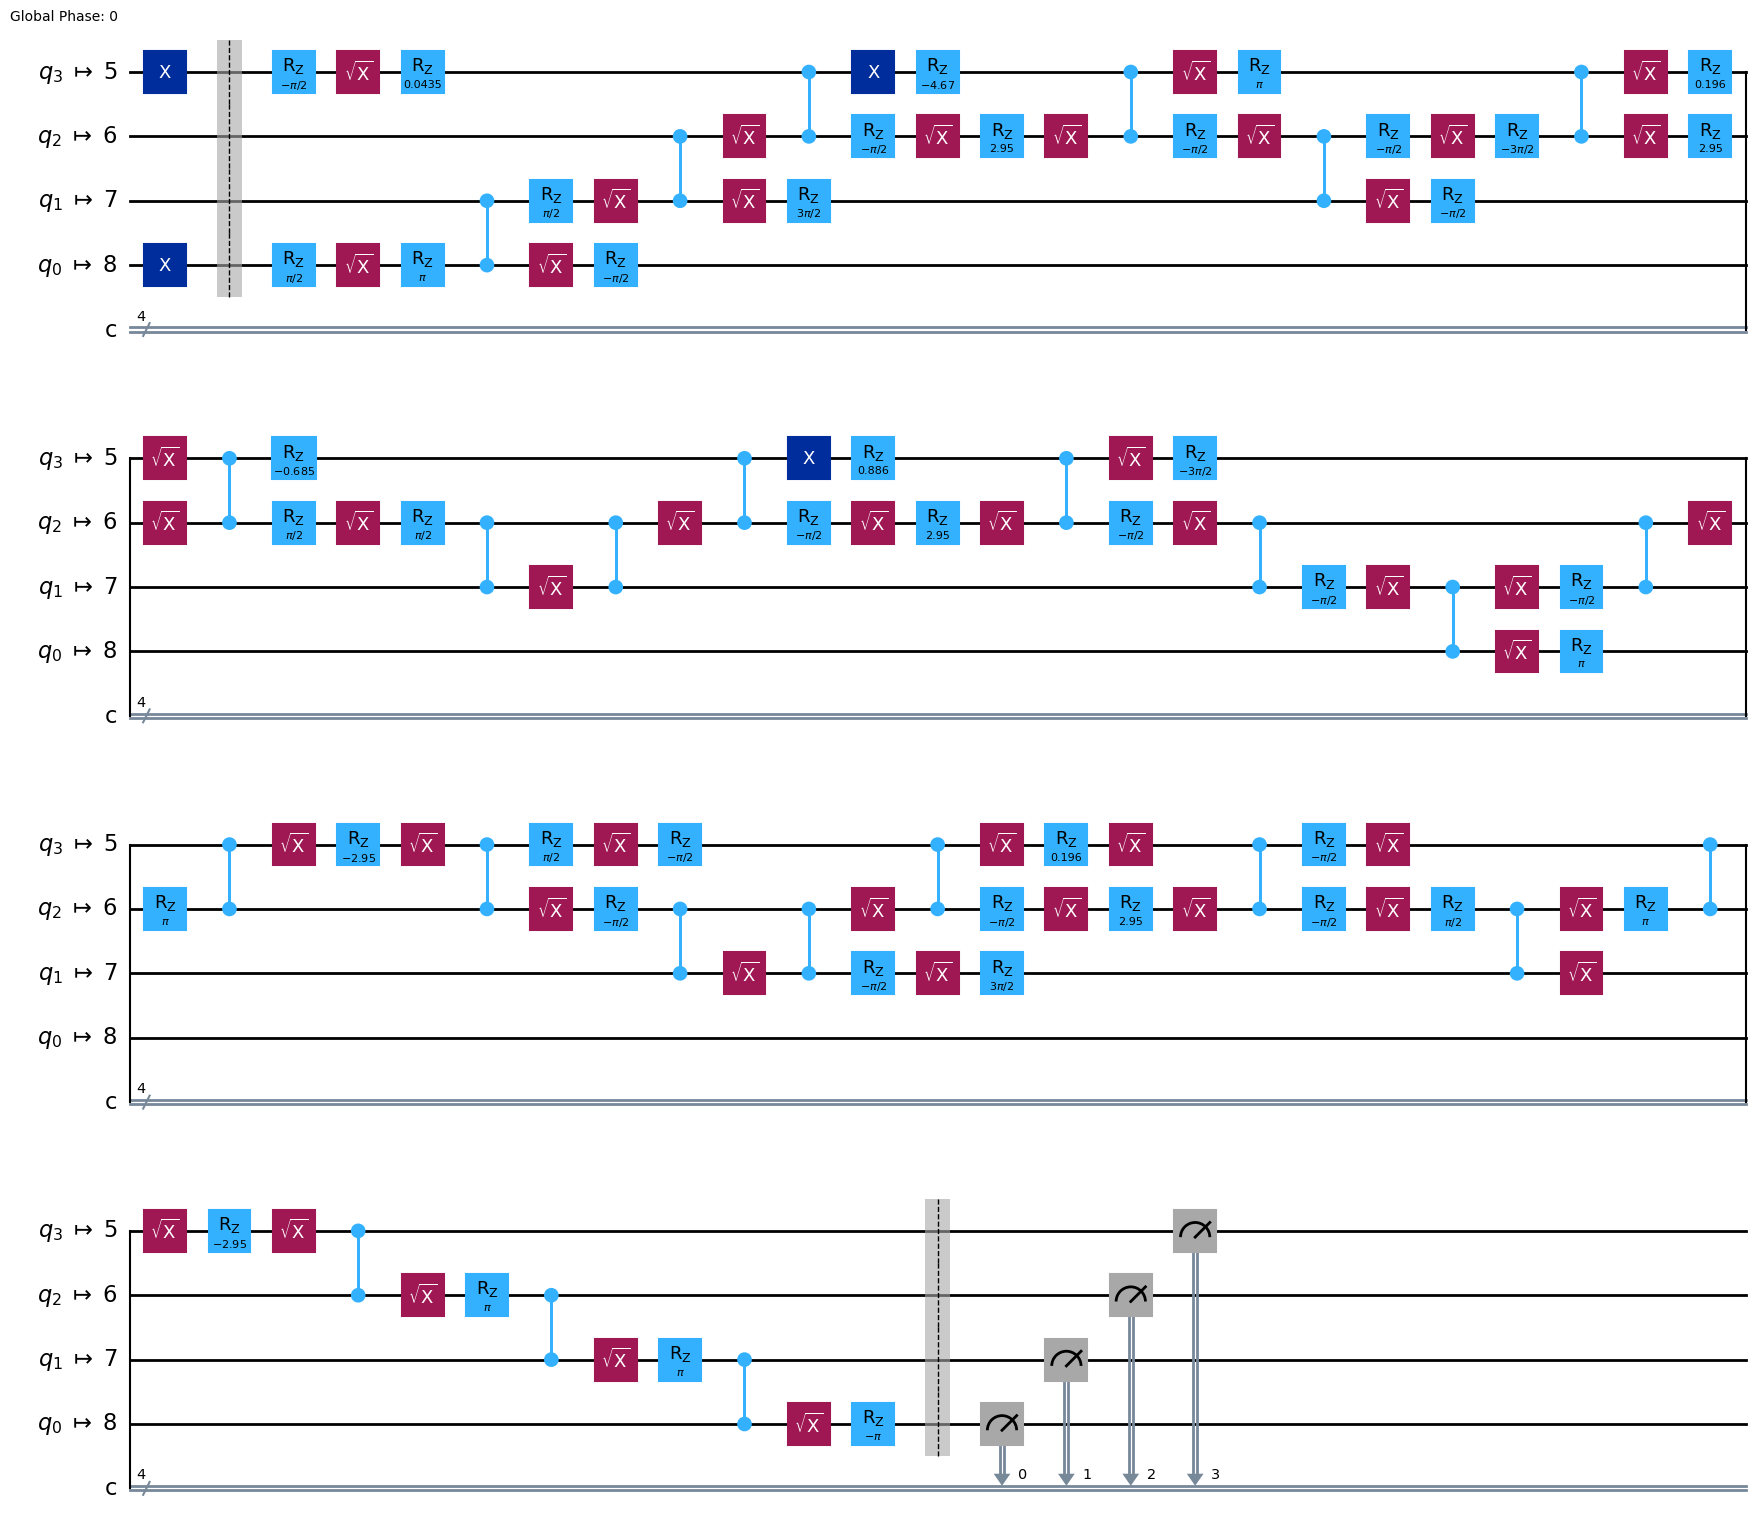

In [26]:
isa_circuit.draw('mpl', idle_wires=False)